In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance
import pandas as pd

In [2]:
df = pd.read_csv("D:\mycode\Fintech-agent\data\macro\combined_macro_data.csv", parse_dates=["date"])

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\manoj\AppData\Local\Temp\ipykernel_9820\3980729896.py:1: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("D:\mycode\Fintech-agent\data\macro\combined_macro_data.csv", parse_dates=["date"])


In [3]:
def rf_gdp_prediction(data, use_macro, model,
                         use_scaling, scaler_type,
                         test_quarters=4):

    macro_vars = [
    "YLDMAT", "DAYMAT", "wti_price",
    "trade_balance", "eci", "nfci", "nfci", "anfci", "nfci_risk", "nfci_credit",
    "nfci_leverage", "nfci_nonfinancial_leverage","gscpi", "long_term_rate",
    "median_cpi", "b30ret","b30ind","b20ret","b20ind","b10ret",
    "b10ind","b7ret","b7ind","b5ret","b5ind","b2ret","b2ind",
    "b1ret","b1ind","t90ret","t90ind","t30ret","t30ind",
    "cpiret","cpiind", "ppi", "real_property_price", "unrate"
    ]

    df = data.copy()
    df = df.sort_values("date")
    dates = df["date"]

    X = df.drop(columns=["gdp", "date"])
    y = df["gdp"]

    if not use_macro:
        X = X.drop(columns=macro_vars, errors="ignore")

    X_train = X.iloc[:-test_quarters]
    X_test  = X.iloc[-test_quarters:]
    y_train = y.iloc[:-test_quarters]
    y_test  = y.iloc[-test_quarters:]
    test_dates = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    steps = []
    if use_scaling:
        scalers = {
            'standard': StandardScaler(),
            'robust':   RobustScaler(),
            'minmax':   MinMaxScaler()
        }
        steps.append(('scaler', scalers.get(scaler_type, StandardScaler())))

    if model == 'RF':
        regressor = RandomForestRegressor(n_estimators=500, random_state=42)
    elif model == 'GB':
        regressor = GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
        )
    elif model == 'XGB':
        regressor = XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, objective='reg:squarederror'
        )
    elif model == 'KNN':
        regressor = KNeighborsRegressor(n_neighbors=5, weights='distance')
    elif model == 'SVR':
        regressor = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    elif model == 'bayes':
        regressor = BayesianRidge()
    elif model == 'catboost':
        regressor = CatBoostRegressor(
            iterations=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=3.0, random_state=42, verbose=0
        )

    steps.append(('model', regressor))
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions  = pipeline.predict(X_test)
    fitted_model = pipeline.named_steps['model']


    mse = mean_squared_error(y_test, predictions)
    r2  = r2_score(y_test, predictions)

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_gdp":    y_test.values,
        "predicted_gdp": predictions
    })
    print(f"\n{'='*55}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*55}")
    for _, row in results.iterrows():
        error = abs(row['actual_gdp'] - row['predicted_gdp'])
        print(f"{row['date'].strftime('%Y-%m-%d'):<15} {row['actual_gdp']:>12.6f} {row['predicted_gdp']:>12.6f} {error:>12.6f}")
    print(f"{'-'*55}")
    print(f"{'MSE:':>40} {mse:>12.6f}")
    print(f"{'R²:':>40} {r2:>12.4f}")
    print(f"{'='*55}")

    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=20, random_state=42)
        importances = perm.importances_mean

    fi_df = pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # Split into macro vs other
    macro_fi = fi_df[fi_df['feature'].isin(macro_vars)].reset_index(drop=True)
    other_fi = fi_df[~fi_df['feature'].isin(macro_vars)].reset_index(drop=True)

    n_plots = 2 + (1 if use_macro and not macro_fi.empty else 0) + (1 if not other_fi.empty else 0)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    axes = np.array(axes).flatten()

    ax_idx = 0

    x = range(len(results))
    axes[ax_idx].plot(x, results["actual_gdp"],    marker="o", label="Actual",    linewidth=2)
    axes[ax_idx].plot(x, results["predicted_gdp"], marker="o", label="Predicted", linewidth=2)
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(results["date"].dt.strftime('%Y-%m-%d'), rotation=45)
    axes[ax_idx].set_xlabel("Quarter")
    axes[ax_idx].set_ylabel("gdp")
    axes[ax_idx].set_title(f"gdp Prediction — {model}\n(R²={r2:.3f}  MSE={mse:.6f})")
    axes[ax_idx].legend()
    axes[ax_idx].grid(True, alpha=0.3)
    ax_idx += 1

    # Macro importance
    if use_macro and not macro_fi.empty:
        axes[ax_idx].barh(macro_fi['feature'][::-1], macro_fi['importance'][::-1], color='steelblue')
        axes[ax_idx].set_title(f"Macro Variable Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1

    #  Other features importance 
    if not other_fi.empty:
        axes[ax_idx].barh(other_fi['feature'][::-1], other_fi['importance'][::-1], color='darkorange')
        axes[ax_idx].set_title(f"Other Feature Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1

    for j in range(ax_idx, len(axes)):
        axes[j].set_visible(False)

    macro_label = "With Macro" if use_macro else "Without Macro"
    plt.suptitle(f"{model} | {macro_label} | Scaler: {scaler_type}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results, mse, r2


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      28708.161000 27954.691666   753.469334
2024-06-30      29147.044000 27910.317689  1236.726311
2024-09-30      29511.664000 27949.539906  1562.124094
2024-12-31      29825.182000 27896.633852  1928.548148
-------------------------------------------------------
                                    MSE: 2064184.413198
                                     R²:     -10.8927


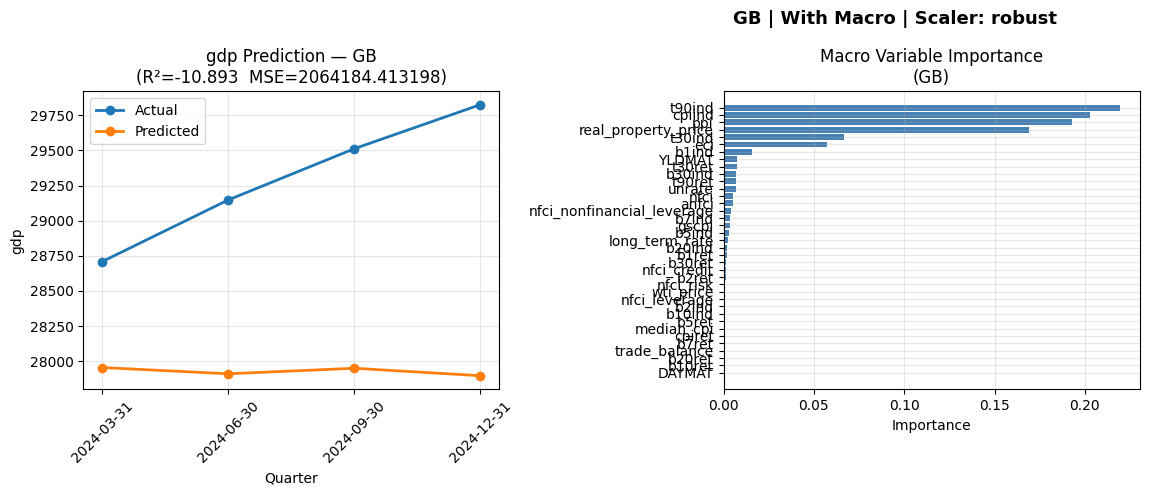

In [12]:

# Usage
results, mse, r2 = rf_gdp_prediction(
    df,
    use_macro=True,
    model='GB',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      28708.161000 27495.702368  1212.458632
2024-06-30      29147.044000 27798.057471  1348.986529
2024-09-30      29511.664000 26707.312636  2804.351364
2024-12-31      29825.182000 27267.952332  2557.229668
-------------------------------------------------------
                                    MSE: 4423407.684166
                                     R²:     -24.4852


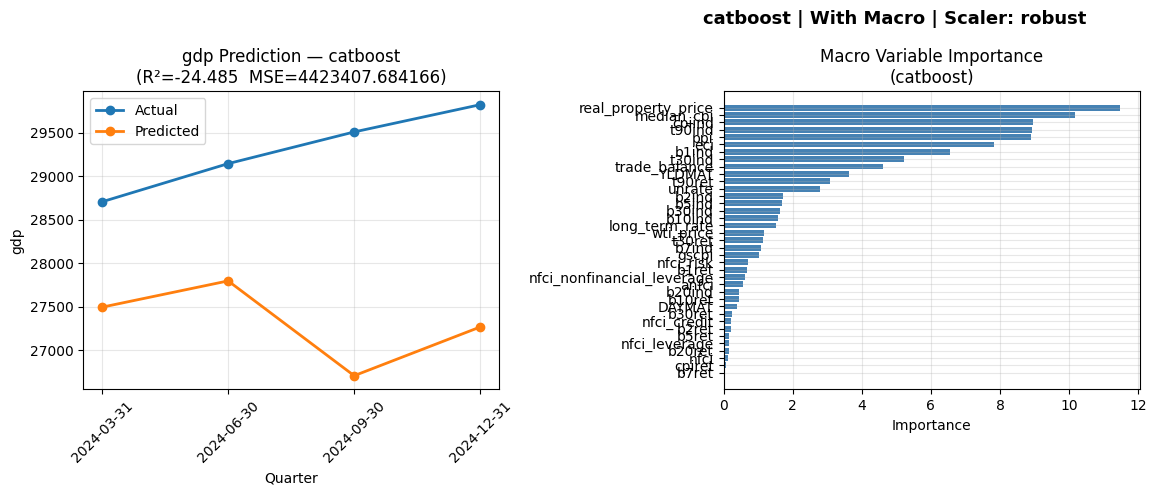

In [10]:

# Usage
results, mse, r2 = rf_gdp_prediction(
    df,
    use_macro=True,
    model='catboost',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      28708.161000 27952.480469   755.680531
2024-06-30      29147.044000 27941.130859  1205.913141
2024-09-30      29511.664000 27878.107422  1633.556578
2024-12-31      29825.182000 27842.878906  1982.303094
-------------------------------------------------------
                                    MSE: 2155828.054367
                                     R²:     -11.4207


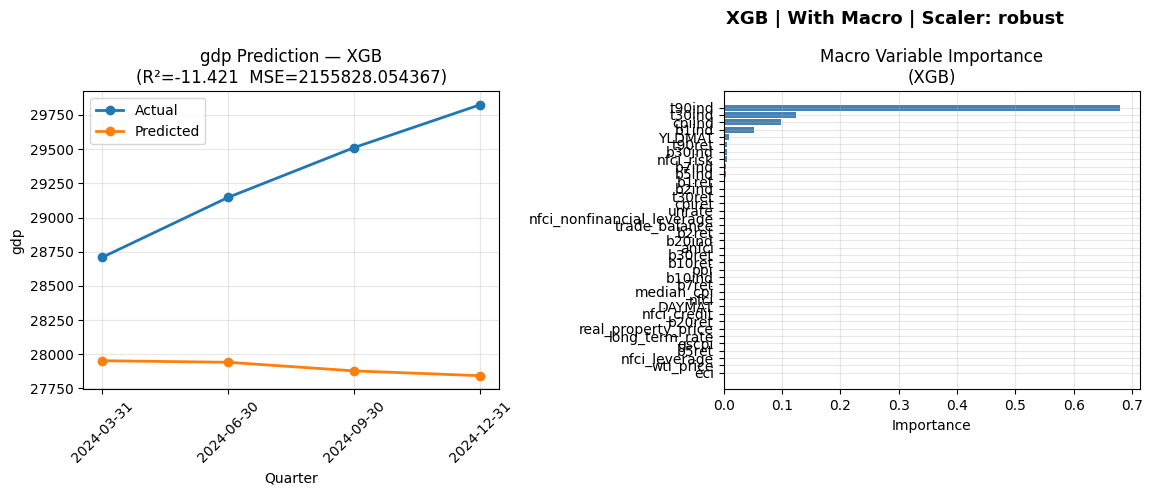

In [5]:

# Usage
results, mse, r2 = rf_gdp_prediction(
    df,
    use_macro=True,
    model='XGB',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      28708.161000 26605.377505  2102.783495
2024-06-30      29147.044000 27621.632455  1525.411545
2024-09-30      29511.664000 26774.206732  2737.457268
2024-12-31      29825.182000 27307.156739  2518.025261
-------------------------------------------------------
                                    MSE: 5145675.580035
                                     R²:     -28.6465


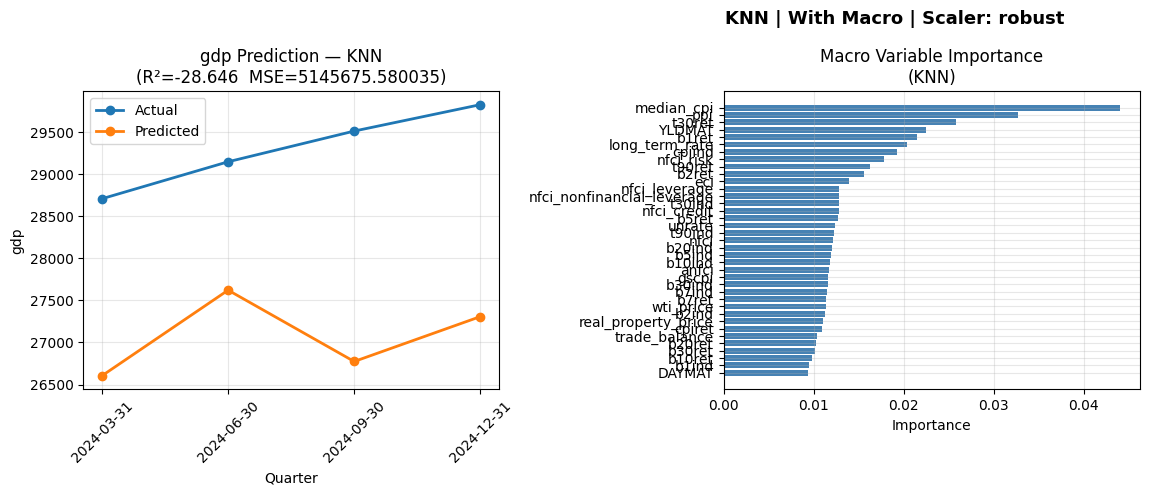

In [8]:

# Usage
results, mse, r2 = rf_gdp_prediction(
    df,
    use_macro=True,
    model='KNN',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      28708.161000 28937.900094   229.739094
2024-06-30      29147.044000 29344.943155   197.899155
2024-09-30      29511.664000 30003.449413   491.785413
2024-12-31      29825.182000 30295.732669   470.550669
-------------------------------------------------------
                                    MSE: 138803.737697
                                     R²:       0.2003


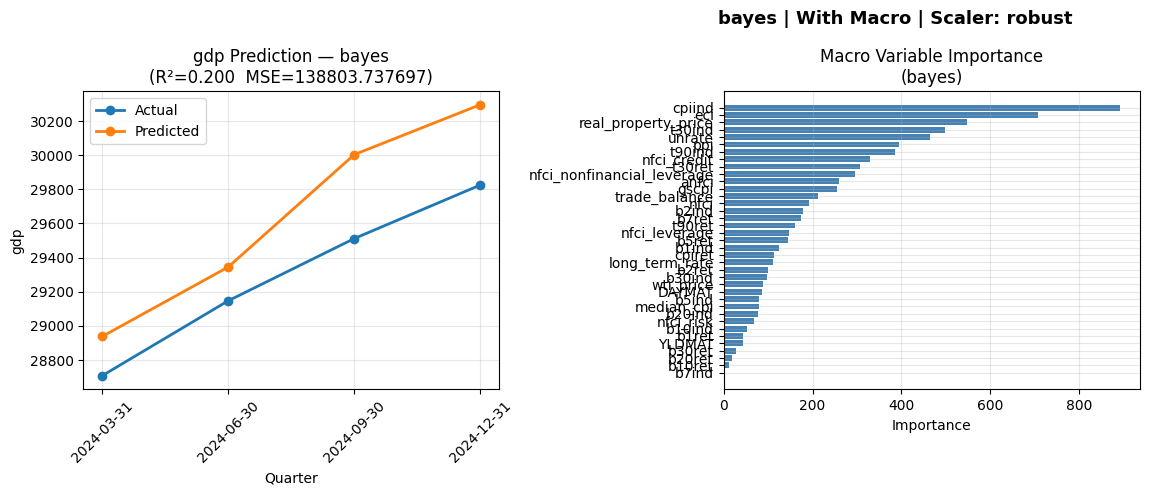

In [6]:

# Usage
results, mse, r2 = rf_gdp_prediction(
    df,
    use_macro=True,
    model='bayes',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      28708.161000 20864.929878  7843.231122
2024-06-30      29147.044000 20865.291391  8281.752609
2024-09-30      29511.664000 20864.161055  8647.502945
2024-12-31      29825.182000 20864.292347  8960.889653
-------------------------------------------------------
                                    MSE: 71295137.817798
                                     R²:    -409.7626


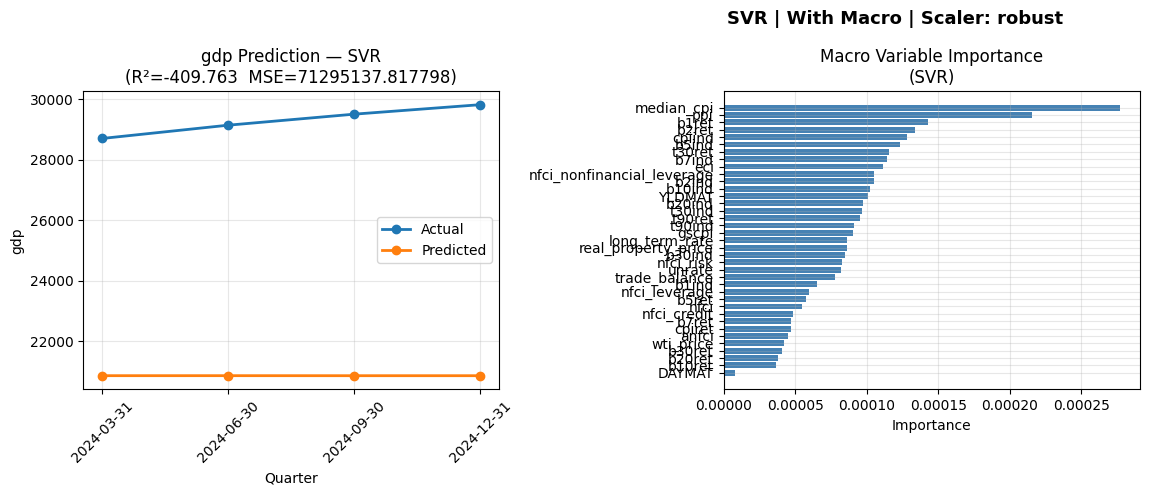

In [9]:

# Usage
results, mse, r2 = rf_gdp_prediction(
    df,
    use_macro=True,
    model='SVR',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      28708.161000 27013.448468  1694.712532
2024-06-30      29147.044000 27396.761118  1750.282882
2024-09-30      29511.664000 26721.938862  2789.725138
2024-12-31      29825.182000 27105.931482  2719.250518
-------------------------------------------------------
                                    MSE: 5278107.614593
                                     R²:     -29.4095


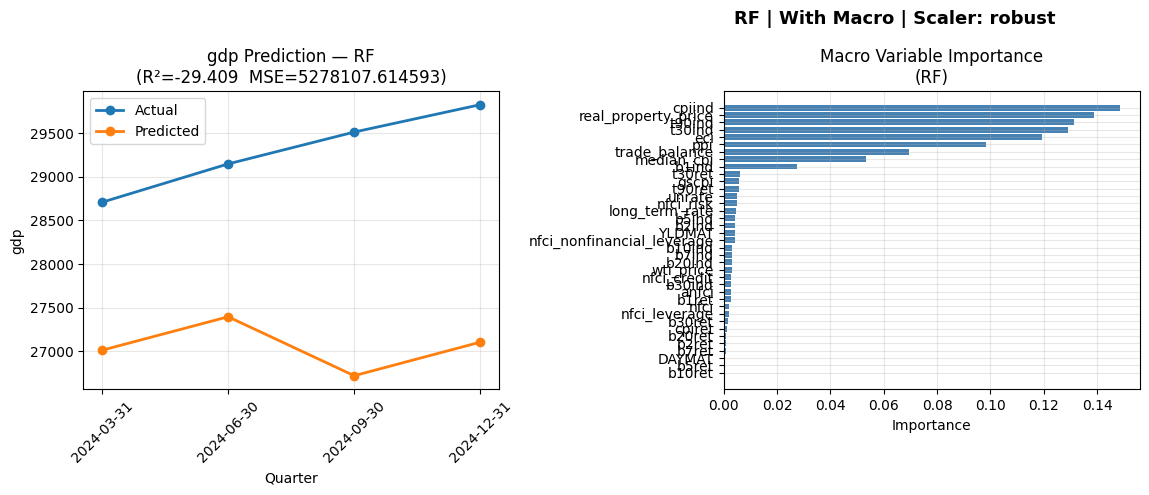

In [7]:

# Usage
results, mse, r2 = rf_gdp_prediction(
    df,
    use_macro=True,
    model='RF',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)